In [1]:
#Importación librerías generales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
#Importación de Machin Learning
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

In [3]:
#Ruta
os.chdir(r"C:\Users\Nefi\OneDrive\Documentos\09-EBAC\EBACMX-DATA-ANALYST\Referencias")

#Cargar datos
df = pd.read_csv("CC_GENERAL.csv")

#Visualización inicial
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
#Preparación de datos, al no tener fecha se crea una serie temporal artificial y se elimina el ID como en el ejericico anteriro se hizo
#Eliminar identificador
df.drop("CUST_ID", axis=1, inplace=True)

#Crear índice temporal
df["Date"] = pd.date_range(start="2020-01-01", periods=len(df), freq="D")

df.set_index("Date", inplace=True)

In [8]:
#Limpieza básica
df = df.dropna(subset=["PURCHASES"])

In [9]:
#Creación de serie temporal
ts = df["PURCHASES"]

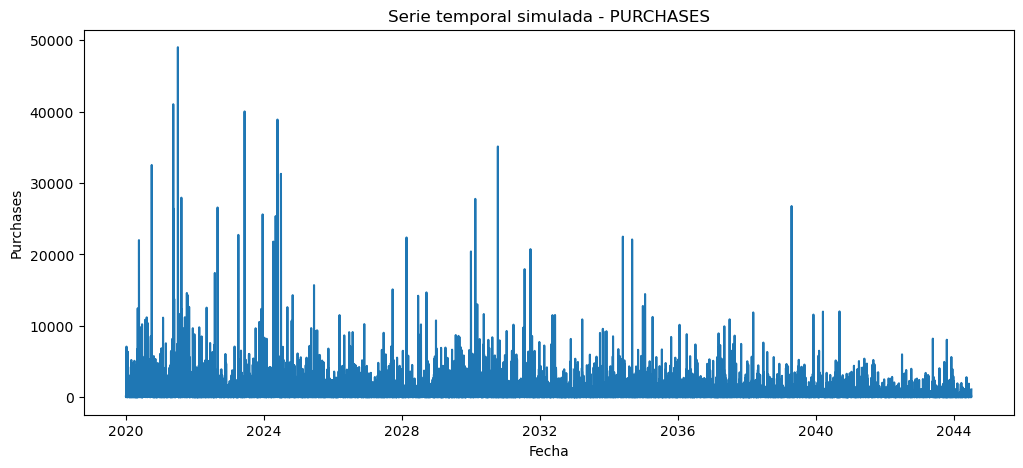

In [10]:
#Visualización de serie temporal
plt.figure(figsize=(12,5))

plt.plot(ts)

plt.title("Serie temporal simulada - PURCHASES")
plt.xlabel("Fecha")
plt.ylabel("Purchases")

plt.show()

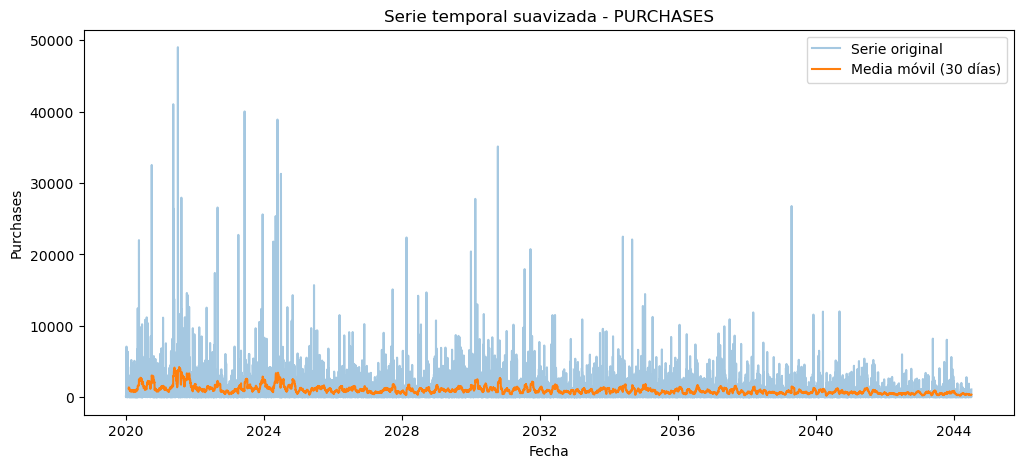

In [11]:
# Media móvil para intentar mejorar el ruido
rolling_mean = ts.rolling(window=30).mean()

plt.figure(figsize=(12,5))

plt.plot(ts, alpha=0.4, label="Serie original")
plt.plot(rolling_mean, label="Media móvil (30 días)")

plt.title("Serie temporal suavizada - PURCHASES")
plt.xlabel("Fecha")
plt.ylabel("Purchases")

plt.legend()

plt.show()

In [13]:
#Modelo de movimiento Browniano-Parámetros
n = len(ts)

In [14]:
#Modelo de movimiento Browniano-Incrementos aleatorios
increments = np.random.normal(loc=0, scale=1, size=n)

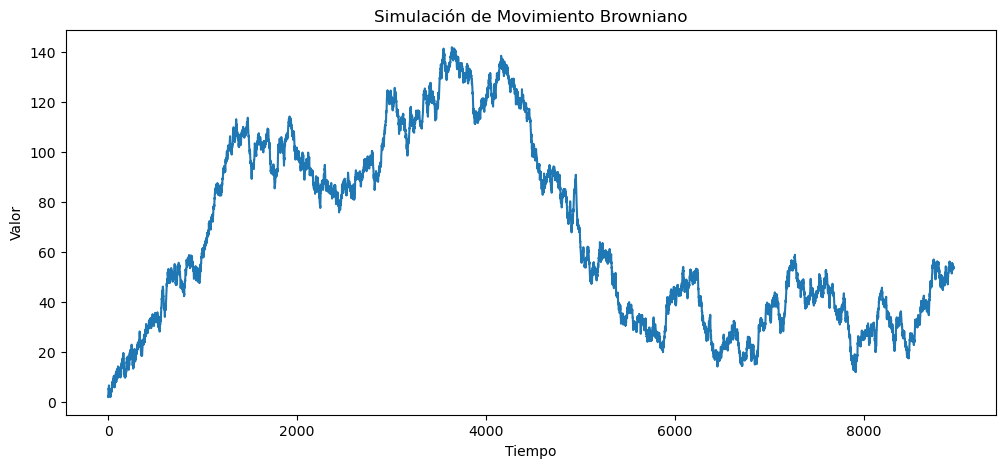

In [15]:
#Modelo de movimiento Browniano-Movimiento
brownian = np.cumsum(increments)

plt.figure(figsize=(12,5))

plt.plot(brownian)

plt.title("Simulación de Movimiento Browniano")
plt.xlabel("Tiempo")
plt.ylabel("Valor")

plt.show()

In [16]:
#Modelo de reversión a la media
theta = 0.15   # velocidad de reversión
mu = ts.mean() # media
sigma = ts.std()

dt = 1
n = len(ts)

mean_reversion = np.zeros(n)
mean_reversion[0] = ts.iloc[0]

for t in range(1, n):
    
    shock = np.random.normal(0, sigma)
    
    mean_reversion[t] = mean_reversion[t-1] + theta * (mu - mean_reversion[t-1]) * dt + shock

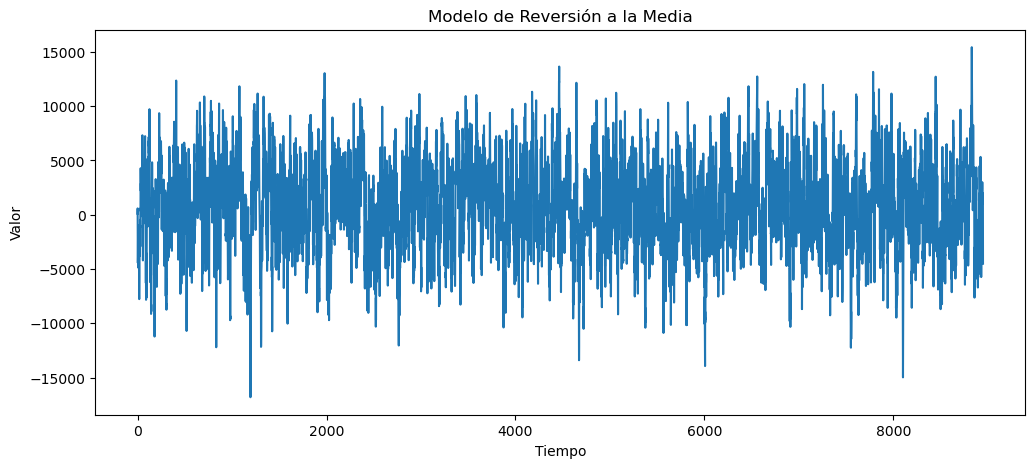

In [17]:
#Visualización del modelo
plt.figure(figsize=(12,5))

plt.plot(mean_reversion)

plt.title("Modelo de Reversión a la Media")
plt.xlabel("Tiempo")
plt.ylabel("Valor")

plt.show()

In [18]:
#Modelo autoregresivo
model_ar = AutoReg(ts, lags=1)

model_ar_fit = model_ar.fit()

print(model_ar_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:              PURCHASES   No. Observations:                 8950
Model:                     AutoReg(1)   Log Likelihood              -81308.597
Method:               Conditional MLE   S.D. of innovations           2136.312
Date:                Mon, 16 Mar 2026   AIC                         162623.193
Time:                        15:37:06   BIC                         162644.491
Sample:                    01-02-2020   HQIC                        162630.442
                         - 07-02-2044                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          986.4477     24.948     39.540      0.000     937.550    1035.345
PURCHASES.L1     0.0168      0.011      1.590      0.112      -0.004       0.038
                                    Roots   

c:\Users\Nefi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [19]:
#Modelo MA
model_ma = ARIMA(ts, order=(0,0,1))

model_ma_fit = model_ma.fit()

print(model_ma_fit.summary())

c:\Users\Nefi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Nefi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Nefi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              PURCHASES   No. Observations:                 8950
Model:                 ARIMA(0, 0, 1)   Log Likelihood              -81317.339
Date:                Mon, 16 Mar 2026   AIC                         162640.677
Time:                        15:37:47   BIC                         162661.976
Sample:                    01-01-2020   HQIC                        162647.927
                         - 07-02-2044                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1003.2048     35.633     28.154      0.000     933.365    1073.045
ma.L1          0.0159      0.013      1.208      0.227      -0.010       0.042
sigma2      4.566e+06   1.41e+04    323.899      0.0

c:\Users\Nefi\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


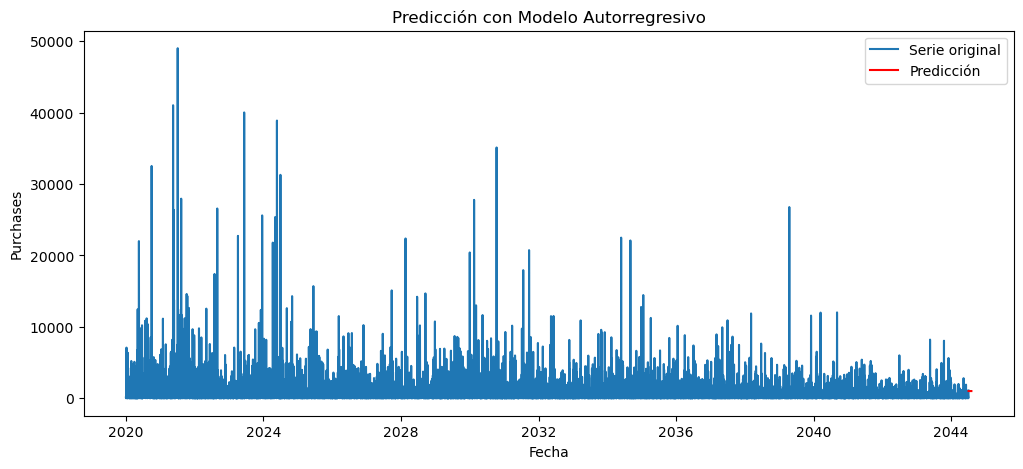

In [20]:
#Predicción con el modelo
forecast = model_ar_fit.predict(start=len(ts), end=len(ts)+30)

plt.figure(figsize=(12,5))

plt.plot(ts, label="Serie original")
plt.plot(forecast, label="Predicción", color="red")

plt.title("Predicción con Modelo Autorregresivo")
plt.xlabel("Fecha")
plt.ylabel("Purchases")

plt.legend()

plt.show()

In [ ]:
#Conclusiones:
#No estoy seguro si fue la práctica correcta pero, se utilizaron diferentes modelos de series de tiempo para simular y 
#analizar el comportamiento de la variable PURCHASES. Debido a que no visualizo un dato temporal real en el dataset,
#se generó una secuencia de fechas artificial para visualizar y modelar la dinámica de la variable.